# Upload data

In [ ]:
import pandas as pd

df = pd.read_csv("/content/german_credit_data.csv")
df

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,12,existing credits paid back duly till now,furniture/equipment,1736,< 100 DM,4 to < 7 years,3,female : divorced/separated/married,none,...,none,31,none,own,1,unskilled - resident,1,none,yes,good
996,< 0 DM,30,existing credits paid back duly till now,car (used),3857,< 100 DM,1 to < 4 years,4,male : divorced/separated,none,...,car,40,none,own,1,management/ self-employed/highly qualified emp...,1,"yes, registered under the customers name",yes,good
997,no checking account,12,existing credits paid back duly till now,radio/television,804,< 100 DM,>= 7 years,4,male : single,none,...,real estate,38,none,own,1,skilled employee/ official,1,none,yes,good
998,< 0 DM,45,existing credits paid back duly till now,radio/television,1845,< 100 DM,1 to < 4 years,4,male : single,none,...,savings agreement/life insurance,23,none,for free,1,skilled employee/ official,1,"yes, registered under the customers name",yes,bad


# Data cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [ ]:
df.isnull().sum()

,0
status_account,0
month_duration,0
credit_history,0
purpose,0
credit_amount,0
status_savings,0
years_employment,0
payment_to_income_ratio,0
status_and_sex,0
secondary_obligor,0


In [ ]:
# تملى القيم الفاضية
df.fillna("unknown", inplace=True)

# Feature Engineering

In [ ]:
df['credit_per_month'] = df['credit_amount'] / df['month_duration']

# Convert the target

In [ ]:
df['Risk'] = df['target'].map({'good': 1, 'bad': 0})
df.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target,credit_per_month,Risk
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good,194.833333,1
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,own,1,skilled employee/ official,1,none,yes,bad,123.979167,0
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,own,1,unskilled - resident,2,none,yes,good,174.666667,1
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,none,for free,1,skilled employee/ official,2,none,yes,good,187.666667,1
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,none,for free,2,skilled employee/ official,2,none,yes,bad,202.916667,0


# Convert Categorical → Numbers

In [ ]:
df = pd.get_dummies(df, drop_first=True)
df.columns = df.columns.str.replace('[^a-zA-Z0-9_]', '_', regex=True)

In [ ]:
df

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors,credit_per_month,Risk,status_account___0_DM,...,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled_employee__official,job_unemployed__unskilled___non_resident,job_unskilled___resident,telephone_yes__registered_under_the_customers_name,is_foreign_worker_yes,target_good
0,6,1169,4,4,67,2,1,194.833333,1,True,...,True,False,True,False,True,False,False,True,True,True
1,48,5951,2,2,22,1,1,123.979167,0,False,...,True,False,True,False,True,False,False,False,True,False
2,12,2096,2,3,49,1,2,174.666667,1,False,...,True,False,True,False,False,False,True,False,True,True
3,42,7882,2,4,45,1,2,187.666667,1,True,...,True,False,False,False,True,False,False,False,True,True
4,24,4870,3,4,53,2,2,202.916667,0,True,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,1736,3,4,31,1,1,144.666667,1,False,...,True,False,True,False,False,False,True,False,True,True
996,30,3857,4,4,40,1,1,128.566667,1,True,...,True,False,True,False,False,False,False,True,True,True
997,12,804,4,4,38,1,1,67.000000,1,False,...,True,False,True,False,True,False,False,False,True,True
998,45,1845,4,4,23,1,1,41.000000,0,True,...,True,False,False,False,True,False,False,True,True,False


# Data partitioning

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Risk", axis=1)
y = df["Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# training model (RandomForest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

# Feature Importance

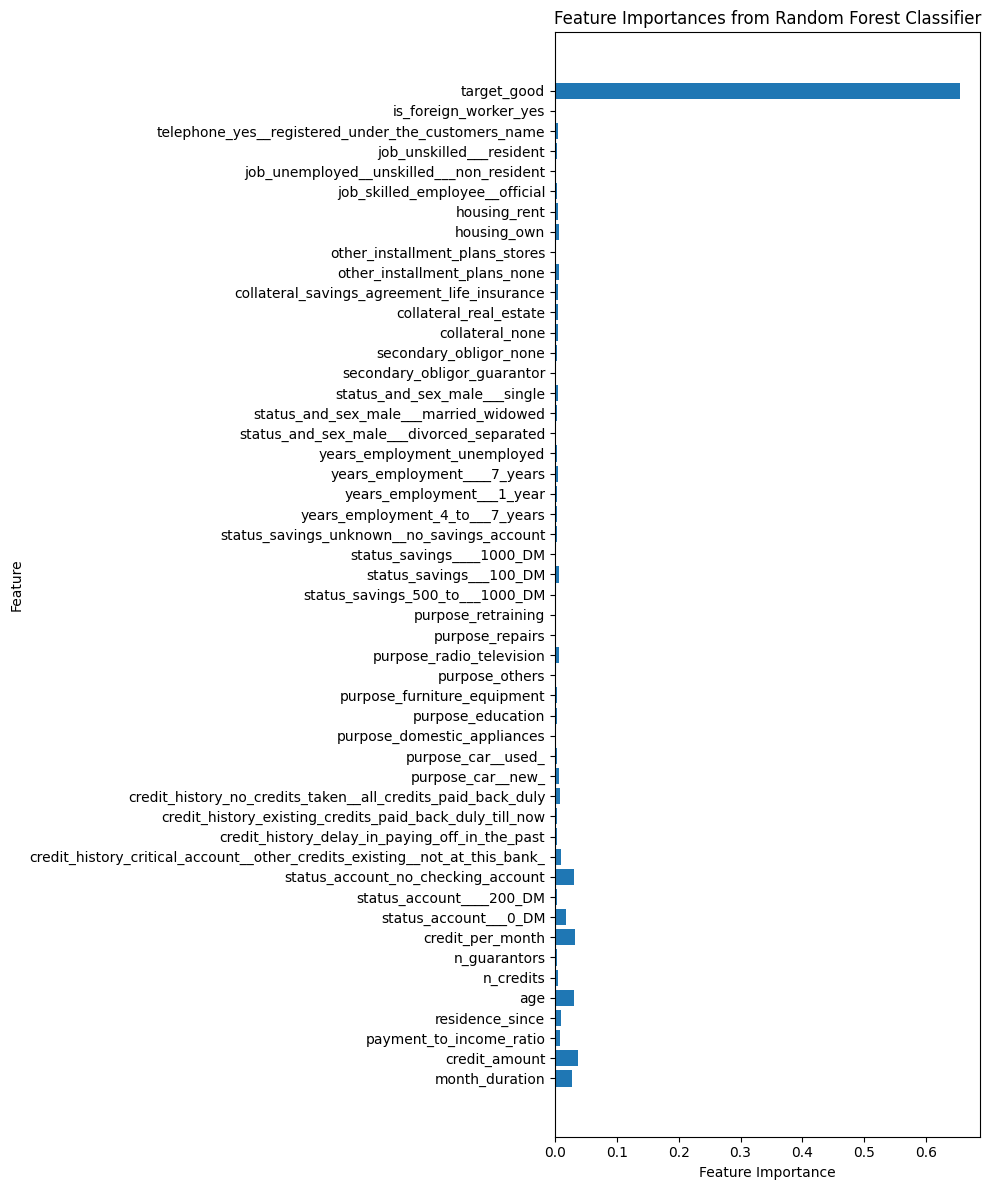

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

# Adjust figure size for better readability
plt.figure(figsize=(10, 12))
plt.barh(X.columns, importance)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importances from Random Forest Classifier")
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       1.00      1.00      1.00       141

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

ROC AUC: 1.0


# Evaluation

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       1.00      1.00      1.00       141

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

ROC AUC: 1.0


# Logistic Regression (Baseline Model)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       1.00      1.00      1.00       141

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

ROC AUC: 1.0


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       1.00      1.00      1.00       141

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

ROC AUC: 0.5281884841928116


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


# XGBoost (Powerful Model)

In [ ]:
pip install xgboost

In [ ]:
from xgboost import XGBClassifier

# Create copies for XGBoost (column names are already cleaned from previous step)
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_xgb, y_train)

y_pred_xgb = xgb_model.predict(X_test_xgb)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test_xgb)[:,1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       1.00      1.00      1.00       141

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

ROC AUC: 1.0


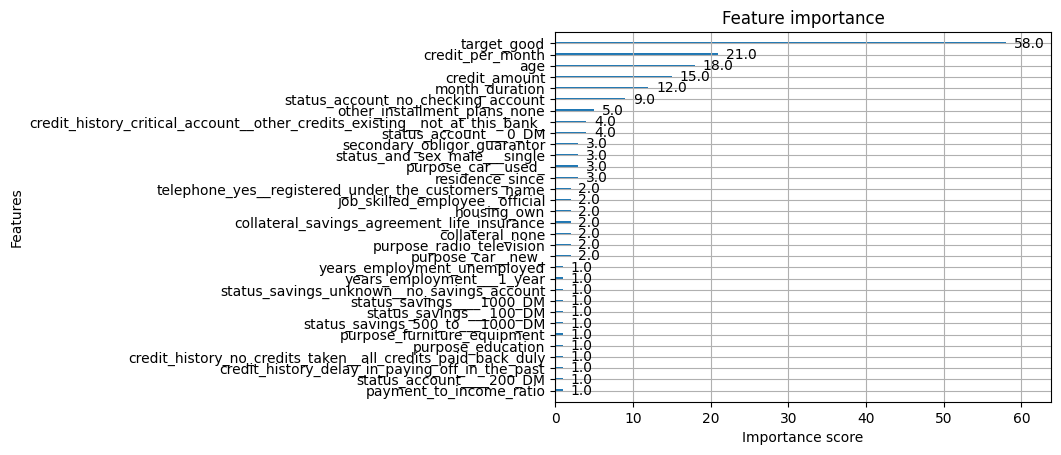

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(xgb_model)
plt.show()

# Model comparison

In [ ]:
print("Logistic ROC AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]))
print("XGBoost ROC AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test_xgb)[:,1]))
print("Random Forest ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

Logistic ROC AUC: 1.0
XGBoost ROC AUC: 1.0
Random Forest ROC AUC: 1.0
